In [ ]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

from enum import Enum

### Hyperparameters

In [2]:
# the number of objects in each world
WORLD_SIZE = 5

# the dimension of the feature vector of each object
# as produced by the encoder
OBJECT_FEATURE_DIMENSION = 6

# the dimension of the speaker's generated vector representation
NEURALESE_DIMENSION = 12

### Model Components

In [3]:
# Speaker-Listener System

class ObjectEncoder(nn.Module):
    """
    Encodes a single (3x3) Object into a feature vector
    Input     : [[001][100][010]] or Purple-Cirle-No-Outline. See metadata.json
    InputSize : (3,3)
    OutputSize: (OBJECT_FEATURE_DIMENSION)
    """
    def __init__(self, output_dimension=OBJECT_FEATURE_DIMENSION):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=2),  # → (batch, 4, 2, 2)
            nn.Flatten(),                    # → (batch, 16)
            nn.Linear(16, output_dimension)
        )

    def forward(self, x):
        return self.encoder(x)
    


class Speaker(nn.Module):
    """
    Transforms the encoded objects in world W + boolean inclusion mask for target subset X
    into a representative vector.

    InputSize : (WORLD_SIZE * OBJECT_FEATURE_DIMENSION) + WORLD_SIZE)
    OutputSize: (NEURALESE_DIMENSION)
    """
    def __init__(self, input_dimension=(WORLD_SIZE * OBJECT_FEATURE_DIMENSION) + WORLD_SIZE,
                 output_dimension=NEURALESE_DIMENSION):
        super().__init__()
        self.speaker_net = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dimension)
        )

    def forward(self, x):
        return self.speaker_net(x)
    


class Listener(nn.Module):
    """
    Takes the resultant vector from the speaker, along with W_i (an element of the world W)
    and predicts whether this element belongs to X, the target subset.

    InputSize : (NEURALESE_DIMENSION + OBJECT_FEATURE_DIMENSION)
    OutputSize: (1) -> logit for binary classification
    """
    def __init__(self, input_dimension=NEURALESE_DIMENSION + OBJECT_FEATURE_DIMENSION,
                 output_dimension=1):
        super().__init__()
        self.listener_net = nn.Sequential(
            nn.Linear(input_dimension, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, output_dimension)
        )

    def forward(self, x):
        return self.listener_net(x)
    


class SpeakerListenerSystem(nn.Module):
    """
    The end-to-end system.
    Encoder -> Speaker -> Listener
    """
    def __init__(self, world_size, feature_dimension, neuralese_dimension):
        super().__init__()

        self.world_size          = world_size
        self.feature_dimension   = feature_dimension
        self.neuralese_dimension = neuralese_dimension

        speaker_input_size  = (self.world_size * self.feature_dimension) + self.world_size
        listener_input_size = self.neuralese_dimension + self.feature_dimension

        self.encoder  = ObjectEncoder(output_dimension=self.feature_dimension)
        self.speaker  = Speaker(input_dimension=speaker_input_size, output_dimension=neuralese_dimension)
        self.listener = Listener(input_dimension=listener_input_size, output_dimension=1)


    def forward(self, W, X_mask, return_neuralese_only=False):
        """
        W:      A batch of worlds.
                Each world is a set of (3x3) objects.
                Tensor of shape (batch_size, world_size, 3, 3).

        X_mask: A batch of boolean masks
                Each value indicated whether the object at that index in W
                is included in the target subset X
                Tensor of shape (batch_size, world_size)
        """
        batch_size = W.shape[0]

        ### STEP 1: Encode all objects in the world
        # Reshape for batch processing ny the encoder (B, 5, 3, 3) -> (B*5, 1, 3, 3)
        W_flat = W.view(-1, 1, 3, 3)
        # Get features for all objects: (B*5, feature_dim)
        object_features_flat = self.encoder(W_flat)
        # Reshape back to per-batch item:(B, 5, feature_dim)
        object_features = object_features_flat.view(batch_size, self.world_size, self.feature_dimension)


        ### STEP 2: Assemble the inputs to the speaker model
        # Flatten object features: (B, 5, feature_dim) -> (B, 5*feature_dim)
        V_W =  object_features.view(batch_size, -1)
        # Create the indicator mask
        M_X = X_mask
        # Concatenate features and mask
        speaker_input = torch.cat([V_W, M_X], dim=1)


        ### STEP 3: Speaker generates neuralese
        # representation has shape (B, neuralese_dimension)
        representation = self.speaker(speaker_input)

        if return_neuralese_only:
            return representation

        ### STEP 4: Prepare the listener's input
        # The listener needs to pair the speaker's representation with each object feature
        # Expand the representation to match the number of objects
        # (B, rep_dim) -> (B, 1, rep_dim) -> (B, world_size, rep_dim)
        r_expanded = representation.unsqueeze(1).repeat(1, self.world_size, 1)
        # Concatenate with object features: (B, 5, rep_dim) + (B, 5, feature_dim)
        listener_input = torch.cat([r_expanded, object_features], dim=2)


        ### STEP 5: Shuffle inputs to the listener
        # This is to avoid the speaker simply learning to tell the listener about X_mask
        # without learning anything about the objects in X themselves.
        # Create a random permutation for each item in the batch
        shuffled_indices = [torch.randperm(self.world_size) for _ in range(batch_size)]
        # Apply the shuffle
        shuffled_input   = torch.stack([features[p] for features, p in zip(listener_input, shuffled_indices)])
        shuffled_labels  = torch.stack([labels[p]   for labels,   p in zip(X_mask, shuffled_indices)])


        ### STEP 6: Listener makes an inclusion prediction for each object
        # Reshape for batch processing by the listener
        # (B, 5, rep_dim + feature_dim) -> (B*5, rep_dim + feature_dim)
        listener_input_flat = shuffled_input.view(-1, self.neuralese_dimension + self.feature_dimension)
        # Get predictions (logits) -> (B*5, 1)
        predictions_flat = self.listener(listener_input_flat)
        # Reshape back to (B, world_size)
        predictions = predictions_flat.view(batch_size, self.world_size)

        return predictions, shuffled_labels

In [29]:
class Translator(nn.Module):
    """
    Translates a neuralese vector V (produced by the speaker) into a sequence of rule tokens
    using an autoregressive LSTM decoder.

    The neuralese vector initializes the hidden state.
    Tokens are generated one at a time, each conditioned on the previous.
    """
    def __init__(self,
                 neuralese_dimension = NEURALESE_DIMENSION,
                 vocab_size          = 13,
                 embed_dimension     = 32,
                 hidden_dimension    = 128,
                 max_rule_length     = 3):
        super().__init__()

        self.vocab_size      = vocab_size
        self.max_rule_length = max_rule_length
        self.hidden_dim      = hidden_dimension

        # Project neuralese vector into LSTM initial hidden + cell states
        self.init_hidden = nn.Linear(neuralese_dimension, hidden_dimension)
        self.init_cell   = nn.Linear(neuralese_dimension, hidden_dimension)

        # Learned embedding for each token in the vocabulary
        # vocab_size + 1 to include a <START> token
        self.embedding = nn.Embedding(vocab_size + 1, embed_dimension)
        self.start_token_idx = vocab_size  # <START> sits just outside the vocabulary

        # The LSTM cell — takes an embedded token, outputs a new hidden state
        self.lstm_cell = nn.LSTMCell(embed_dimension, hidden_dimension)

        # Project hidden state to logits over the vocabulary
        self.output_projection = nn.Linear(hidden_dimension, vocab_size)


    def forward(self, V, target_tokens=None):
        """
        V:             Neuralese vectors.          (batch_size, neuralese_dimension)
        target_tokens: Ground truth token indices. (batch_size, max_rule_length)
                       If provided, uses teacher forcing (training mode).
                       If None, generates autoregressively (inference mode).

        Returns:
        logits:        (batch_size, max_rule_length, vocab_size)
        """
        batch_size = V.shape[0]

        # Initialize hidden and cell states from the neuralese vector
        h = torch.tanh(self.init_hidden(V))  # (batch_size, hidden_dim)
        c = torch.tanh(self.init_cell(V))    # (batch_size, hidden_dim)

        # Kick off the sequence with the <START> token
        start_tokens = torch.full((batch_size,), self.start_token_idx,
                                  dtype=torch.long, device=V.device)
        current_input = self.embedding(start_tokens)  # (batch_size, embed_dim)

        logits = []

        for t in range(self.max_rule_length):

            # One LSTM step
            h, c = self.lstm_cell(current_input, (h, c))

            # Project to vocabulary logits
            step_logits = self.output_projection(h)  # (batch_size, vocab_size)
            logits.append(step_logits)

            # Decide next input: teacher forcing during training, argmax during inference
            if target_tokens is not None:
                current_input = self.embedding(target_tokens[:, t])
            else:
                predicted = torch.argmax(step_logits, dim=1)
                current_input = self.embedding(predicted)

        return torch.stack(logits, dim=1)  # (batch_size, max_rule_length, vocab_size)

### Data Loading

In [5]:
def generate_batch(batch_size, world_size):
    """Generates a batch of dummy data"""

    # Random 3x3 objects for the world
    W_batch = torch.rand(batch_size, world_size, 3, 3)

    # Random binary masks
    X_mask_batch = torch.randint(0, 2, (batch_size, world_size)).float()

    # Ensure at least one object is selected in each world
    for i in range(batch_size):
        if X_mask_batch[i].sum() == 0:
            # Randomly select one object
            X_mask_batch[i, random.randint(0, world_size-1)] = 1.0


    return W_batch, X_mask_batch

In [6]:
def load_dataset(path='../data/dataset.npz'):
    """Load the real dataset from npz file"""

    data = np.load(path, allow_pickle=True)

    W = data['W']
    X_mask = data['X_mask']
    rule_encodings = data['rule_encodings']
    rule_texts = data['rule_texts']

    # Load metadata
    metadata_path = path.replace('.npz', '_metadata.json')
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    return W, X_mask, rule_encodings, rule_texts, metadata

In [7]:
def split_dataset(W, X_mask, rule_encodings, rule_texts,
                speaker_listener_ratio=0.5,
                translator_train_ratio=0.4,
                translator_test_ratio =0.1,
                seed=42):

    """
    Split dataset into three portions with shuffling:
    1. Speaker-Listener training (50%)
    2. Translator training (40%)
    3. Translator testing (10%)

    Args:
        W: World matrices [N, 5, 3, 3]
        X_mask: Subset masks [N, 5]
        rule_encodings: Rule encodings [N, ...]
        rule_texts: Rule text strings [N]
        speaker_listener_ratio: Fraction for speaker-listener
        translator_train_ratio: Fraction for translator training
        translator_test_ratio: Fraction for translator testing
        seed: Random seed for reproducibility

    Returns:
        Dictionary with all splits
    """

    assert abs(speaker_listener_ratio + translator_train_ratio + translator_test_ratio - 1.0) < 1e-6, \
           "Ratios must sum to 1.0"
    np.random.seed(seed)

    # Shuffle the dataset
    N_total = len(W)
    indices = np.random.permutation(N_total)

    # Calculate sizes of data portions
    speaker_listener_size = int(N_total * speaker_listener_ratio)
    translator_train_size = int(N_total * translator_train_ratio)
    translator_test_size  = int(N_total * translator_test_ratio)

    # Calculate indices for splitting
    speaker_listener_idx = indices[:speaker_listener_size]
    translator_train_idx = indices[speaker_listener_size:speaker_listener_size + translator_train_size]
    translator_test_idx  = indices[speaker_listener_size + translator_train_size:]

    # Split the data
    split_dataset = {
        'speaker_listener': {
            'W':              torch.tensor(W[speaker_listener_idx]).float(),
            'X_mask':         torch.tensor(X_mask[speaker_listener_idx]).float(),
            'rule_encodings': rule_encodings[speaker_listener_idx],
            'rule_texts':     rule_texts[speaker_listener_idx]
        },
        'translator_train': {
            'W':              torch.tensor(W[translator_train_idx]).float(),
            'X_mask':         torch.tensor(X_mask[translator_train_idx]).float(),
            'rule_encodings': rule_encodings[translator_train_idx],
            'rule_texts':     rule_texts[translator_train_idx]
        },
        'translator_test': {
            'W':              torch.tensor(W[translator_test_idx]).float(),
            'X_mask':         torch.tensor(X_mask[translator_test_idx]).float(),
            'rule_encodings': rule_encodings[translator_test_idx],
            'rule_texts':     rule_texts[translator_test_idx]
        }
    }

    print("Dataset Split:")
    print(f"  Speaker-Listener:  {len(speaker_listener_idx):,} ({speaker_listener_ratio*100:.0f}%)")
    print(f"  Translator Train:  {len(translator_train_idx):,} ({translator_train_ratio*100:.0f}%)")
    print(f"  Translator Test:   {len(translator_test_idx):,}  ({translator_test_ratio*100:.0f}%)")
    print(f"  Total:             {N_total:,}")

    return split_dataset

In [8]:
# Load dataset and split
W_data, X_mask_data, rule_encodings_data, rule_texts_data, metadata = load_dataset('../data/dataset.npz')
dataset_splits = split_dataset(W_data, X_mask_data, rule_encodings_data, rule_texts_data)

def load_batch(split_name, start_idx, batch_size, include_rules=False):
    """Load a batch of data from the specified split"""
    split = dataset_splits[split_name]
    end_idx = start_idx + batch_size

    Wb = split['W'][start_idx:end_idx]
    Xb = split['X_mask'][start_idx:end_idx]

    if include_rules:
        rb = split['rule_tokens'][start_idx:end_idx]
        return Wb, Xb, rb

    return Wb, Xb

Dataset Split:
  Speaker-Listener:  852,916 (50%)
  Translator Train:  682,333 (40%)
  Translator Test:   170,584  (10%)
  Total:             1,705,833


### Visualizations

In [9]:
def plot_metric(values, step_size, metric_name, save_path=None, figsize=(10,6)):
    """
    Plot training metric (loss or accuracy) over epochs

    Args:
        values: List or array of metric values recorded during training
        step_size: Number of epochs between each recorded value (e.g., 50 if you log every 50 epochs)
        metric_name: Name of the metric for labels (e.g., 'Loss', 'Accuracy')
        save_path: Optional path to save the figure (e.g., 'speaker_loss.png')
        figsize: Tuple specifying figure size (width, height)

    Example:
        plot_metric(losses, 50, 'Loss', save_path='speaker_loss.png')
        plot_metric(accuracies, 50, 'Accuracy', save_path='speaker_accuracy
    """

    # Calculate epochs based on step size
    epochs = np.arange(step_size, len(values)*step_size + 1, step_size)

    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(epochs, values, linewidth=2, color="#B41F1F" if 'loss' in metric_name.lower() else "#35B457")

    # Styling
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(f'{metric_name} over Training', fontsize=14)

    # Tight layout for better spacing
    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

### Load Trained Speaker-Listener Model
Before running this notebook, ensure `speaker_listener.pt` exists in this folder.

In [ ]:
# Load the trained speaker-listener model
checkpoint = torch.load('models/speaker_listener.pt')

hp = checkpoint['hyperparameters']
speaker_listener = SpeakerListenerSystem(
    world_size          = hp['world_size'],
    feature_dimension   = hp['object_feature_dimension'],
    neuralese_dimension = hp['neuralese_dimension'],
)
speaker_listener.load_state_dict(checkpoint['model_state_dict'])
speaker_listener.eval()

for param in speaker_listener.parameters():
    param.requires_grad = False

print("Speaker-listener model loaded and frozen.")

Speaker-listener model loaded and frozen.


## The Translator

### Prepare Translator Data

In [11]:
# map vocabulary to tokens
VOCABULARY = {
    '<blank>'      : 0,
    'not'          : 1,
    'and'          : 2,
    'or'           : 3,
    'red'          : 4,
    'green'        : 5,
    'purple'       : 6,
    'circle'       : 7,
    'square'       : 8,
    'triangle'     : 9,
    'no-outline'   : 10,
    'slim-outline' : 11,
    'thick-outline': 12
}
IDX_TO_TOKEN = {v: k for k, v in VOCABULARY.items()}

In [12]:
# Convert rules to token sequences
def rule_text_to_tokens(rule_text, max_rule_length=3):
    """
    Convert rule text string into a fixed-length sequence of tokens.

    Arguments:
        rule_text: String representation of the rule (e.g., "red and circle")
        max_rule_length: Fixed sequence length (default 3)

    Returns:
        List of token indices representing the rule, padded with <blank> tokens.
    """
    tokens = rule_text.split()
    token_indices = [VOCABULARY[token] for token in tokens]

    # Pad with <blank> tokens if necessary
    while len(token_indices) < max_rule_length:
        token_indices.append(VOCABULARY['<blank>'])

    return token_indices[:max_rule_length]


train_rule_tokens = [
    rule_text_to_tokens(rule_text)
    for rule_text in dataset_splits['translator_train']['rule_texts']
]

test_rule_tokens = [
    rule_text_to_tokens(rule_text)
    for rule_text in dataset_splits['translator_test']['rule_texts']
]
train_targets = torch.tensor(train_rule_tokens, dtype=torch.long)
test_targets  = torch.tensor(test_rule_tokens, dtype=torch.long)

# Add tokenized rules to dataset splits
dataset_splits['translator_train']['rule_tokens'] = train_targets
dataset_splits['translator_test']['rule_tokens']  = test_targets

# Print shapes and examples
print(f"Train targets shape: {train_targets.shape}")
print(f"Test targets shape : {test_targets.shape}")
print(f"\nFirst 5 train examples:")
for i in range(5):
    rule_text = dataset_splits['translator_train']['rule_texts'][i]
    tokens = train_targets[i].tolist()
    decoded = [IDX_TO_TOKEN[t] for t in tokens]
    print(f"  '{rule_text}' -> {tokens} -> {decoded}")


Train targets shape: torch.Size([682333, 3])
Test targets shape : torch.Size([170584, 3])

First 5 train examples:
  'green and triangle' -> [5, 2, 9] -> ['green', 'and', 'triangle']
  'not square' -> [1, 8, 0] -> ['not', 'square', '<blank>']
  'purple or square' -> [6, 3, 8] -> ['purple', 'or', 'square']
  'triangle or slim-outline' -> [9, 3, 11] -> ['triangle', 'or', 'slim-outline']
  'circle' -> [7, 0, 0] -> ['circle', '<blank>', '<blank>']


### Training

In [13]:
# Hyperparameters for training
BATCH_SIZE    = 32 # 32
NUM_EPOCHS    = 15 # 2000
LEARNING_RATE = 1e-4

N_DATA = len(dataset_splits['translator_train']['W'])

In [32]:
translator_model = Translator(
    neuralese_dimension = NEURALESE_DIMENSION,
    vocab_size          = len(VOCABULARY),
    embed_dimension     = 32,
    hidden_dimension    = 128,
    max_rule_length     = 3,
)

translator_optimizer = optim.Adam(translator_model.parameters(), lr=1e-3)
translator_criterion = nn.CrossEntropyLoss()

In [15]:
# Calculate neuralese statistics for normalization
print("Computing neuralese statistics from translator_train...")

all_neuralese = []

with torch.no_grad():
    for start_idx in range(0, N_DATA, BATCH_SIZE):
        batch_size = min(BATCH_SIZE, N_DATA - start_idx)

        # collect data from translator train
        Wb, Xb = load_batch('translator_train', start_idx, batch_size)

        # compute the neuralese via the frozen speaker
        Vb = speaker_listener(Wb, Xb, return_neuralese_only=True)
        all_neuralese.append(Vb)

# concatenate all neuralese vectors
all_neuralese = torch.cat(all_neuralese, dim=0) # (N_DATA, neuralese_dimension)

# compute statistics
neuralese_mean = all_neuralese.mean(dim=0) # 12
neuralese_std  = all_neuralese.std(dim=0)

print(f"Neuralese mean: {neuralese_mean}")
print(f"Neuralese std : {neuralese_std}")

Computing neuralese statistics from translator_train...
Neuralese mean: tensor([-0.9473,  6.5567, -3.5357,  1.7435, -9.0126,  9.1548, -5.7529,  1.2613,
         6.9551, -6.7343, -1.3457,  0.2404])
Neuralese std : tensor([1.6304, 1.6894, 1.9658, 1.5834, 2.0234, 2.4538, 1.8573, 1.6224, 2.2969,
        1.7448, 1.2031, 1.1943])


In [33]:
# Training loop
step = 0
start_index = 0

losses = []
token_accuracies = []
sequence_accuracies = []

print("Starting translator training...")
for epoch in range(NUM_EPOCHS):
    start_index = 0

    # Stop when we run out of data
    while start_index < N_DATA:
        batch_size = min(BATCH_SIZE, N_DATA - start_index)

        # Load a batch of translator training data
        W_batch, X_mask_batch, rule_tokens_batch = load_batch(
            'translator_train', start_index, batch_size, include_rules=True
        )
        start_index += BATCH_SIZE
        step += 1

        # Get the neuralese representations from the frozen speaker
        with torch.no_grad():
            # (batch_size, neuralese_dimension)
            V_batch = speaker_listener(W_batch, X_mask_batch, return_neuralese_only=True)

        # Normalize the neuralese
        V_batch = (V_batch - neuralese_mean) / (neuralese_std + 1e-8)

        # Predict the rule tokens
        # (batch_size, max_rule_length, vocab_size)
        translator_optimizer.zero_grad()
        predicted_logits = translator_model(V_batch, target_tokens=rule_tokens_batch)

        # Calculate loss for each position in the rule
        loss = translator_criterion(
            predicted_logits.view(-1, len(VOCABULARY)),  # (batch_size * max_rule_length, vocab_size)
            rule_tokens_batch.view(-1)                   # (batch_size * max_rule_length,)
        )

        # Optimize
        loss.backward()
        translator_optimizer.step()

        if (step + 1) % 500 == 0:
            # Track data consumption
            print(f"Epoch: {epoch}. start_index: {start_index}, end_index: {start_index + batch_size}")

            # Calculate token-level accuracy
            predicted_tokens = torch.argmax(predicted_logits, dim=2)  # (batch_size, max_rule_length)
            correct_tokens   = (predicted_tokens == rule_tokens_batch).float()
            token_accuracy   = correct_tokens.mean().item()

            # Calculate sequence-level accuracy
            sequence_correct = (correct_tokens.sum(dim=1) == correct_tokens.shape[1]).float()
            sequence_accuracy = sequence_correct.mean().item()

            print(f"Step [{step+1}/{NUM_EPOCHS * (N_DATA // BATCH_SIZE) + 1}], Loss: {loss.item():.4f}, Token Acc: {token_accuracy:.4f}, Seq Acc: {sequence_accuracy:.4f}")

            # Store metrics
            losses.append(loss.item())
            token_accuracies.append(token_accuracy)
            sequence_accuracies.append(sequence_accuracy)

print("Translator training finished.")


Starting translator training...
Epoch: 0. start_index: 15968, end_index: 16000
Step [500/319831], Loss: 1.0119, Token Acc: 0.6250, Seq Acc: 0.2188
Epoch: 0. start_index: 31968, end_index: 32000
Step [1000/319831], Loss: 0.9558, Token Acc: 0.6667, Seq Acc: 0.2812
Epoch: 0. start_index: 47968, end_index: 48000
Step [1500/319831], Loss: 0.9450, Token Acc: 0.6250, Seq Acc: 0.1875
Epoch: 0. start_index: 63968, end_index: 64000
Step [2000/319831], Loss: 0.7594, Token Acc: 0.7396, Seq Acc: 0.4062
Epoch: 0. start_index: 79968, end_index: 80000
Step [2500/319831], Loss: 0.9119, Token Acc: 0.6771, Seq Acc: 0.2188
Epoch: 0. start_index: 95968, end_index: 96000
Step [3000/319831], Loss: 0.8731, Token Acc: 0.6667, Seq Acc: 0.2812
Epoch: 0. start_index: 111968, end_index: 112000
Step [3500/319831], Loss: 0.7622, Token Acc: 0.7708, Seq Acc: 0.4688
Epoch: 0. start_index: 127968, end_index: 128000
Step [4000/319831], Loss: 0.8408, Token Acc: 0.6458, Seq Acc: 0.3125
Epoch: 0. start_index: 143968, end_in

Plot saved to ../images/lstm_translator_loss.png


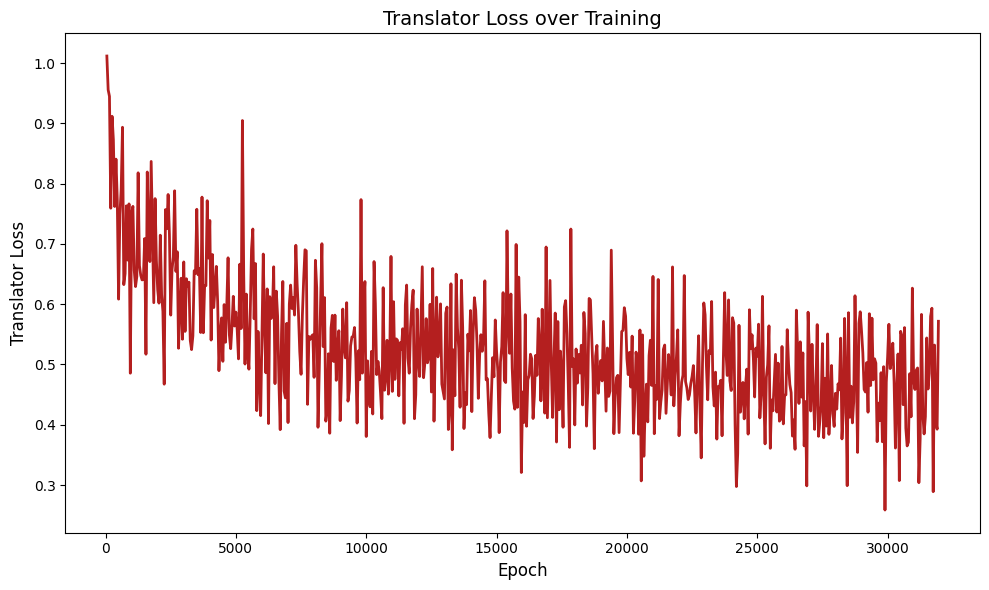

Plot saved to ../images/lstm_translator_token_accuracy.png


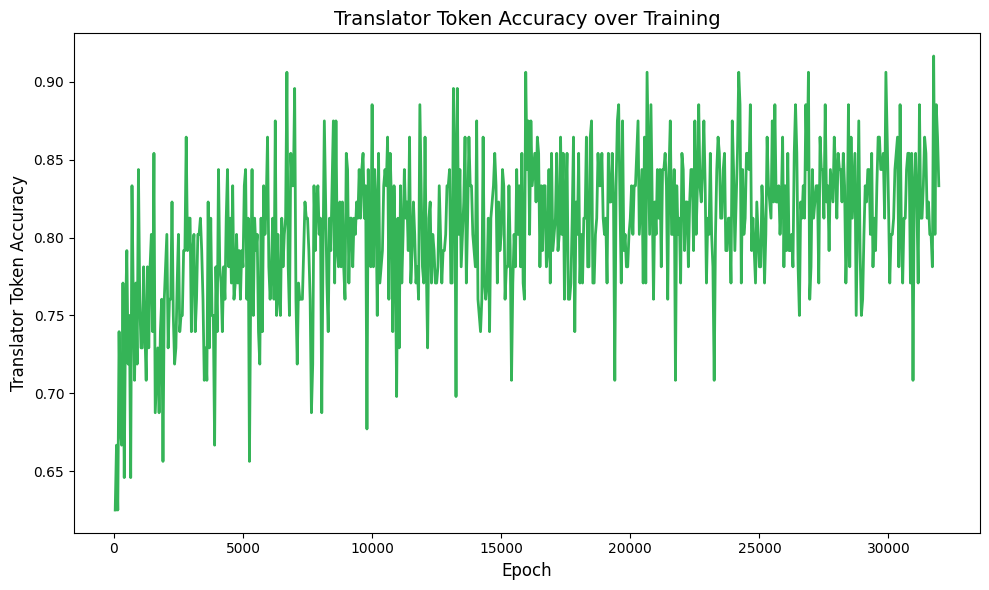

Plot saved to ../images/lstm_translator_sequence_accuracy.png


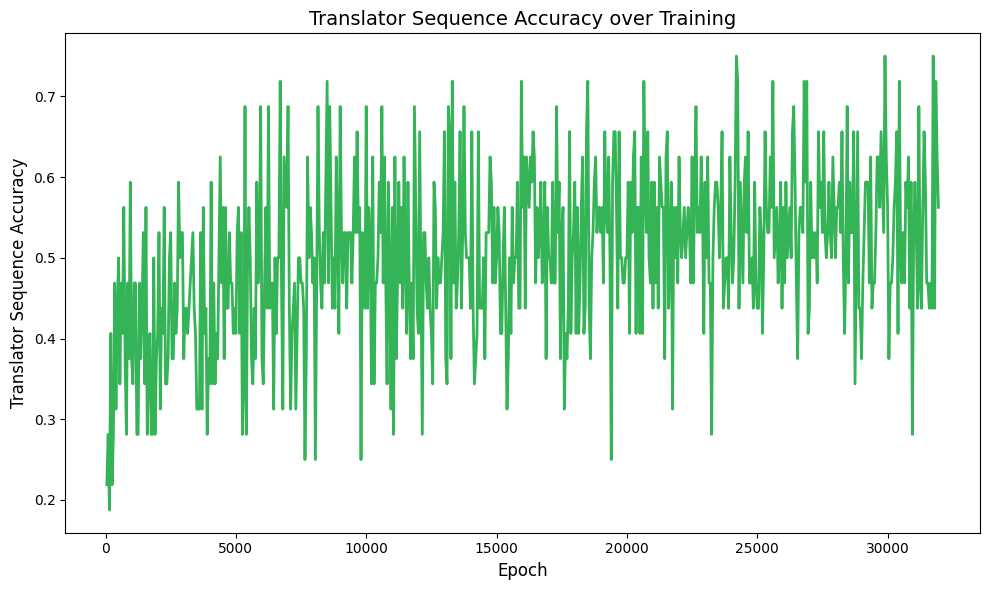

In [34]:
# Training graphs
plot_metric(losses, step_size=50, metric_name='Translator Loss', save_path='../images/lstm_translator_loss.png')
plot_metric(token_accuracies, step_size=50, metric_name='Translator Token Accuracy', save_path='../images/lstm_translator_token_accuracy.png')
plot_metric(sequence_accuracies, step_size=50, metric_name='Translator Sequence Accuracy', save_path='../images/lstm_translator_sequence_accuracy.png')

### Inference

In [35]:
# Freeze translator model parameters
for param in translator_model.parameters():
    param.requires_grad = False

translator_model.eval()

Translator(
  (init_hidden): Linear(in_features=12, out_features=128, bias=True)
  (init_cell): Linear(in_features=12, out_features=128, bias=True)
  (embedding): Embedding(14, 32)
  (lstm_cell): LSTMCell(32, 128)
  (output_projection): Linear(in_features=128, out_features=13, bias=True)
)

In [36]:
class SemanticError(Enum):
    """Types of semantic errors in rule translation."""
    VALID = "valid"
    AND_SAME_TYPE = "and_same_type"
    DUPLICATE_FEATURE = "duplicate_feature"
    MALFORMED_RULE = "malformed_rule"
    
    def __str__(self):
        return self.value
    
    def __repr__(self):
        return f"SemanticError.{self.name}"


def check_semantic_translation(tokens):
    '''
    Check if tokens form a valid semantic rule.

    Arguments: 
    tokens: list of token indices representing a rule
    e.g., ['red', 'and', 'circle']

    Returns:
    tuple: (is_valid: bool, error: SemanticError)
        If valid: (True, SemanticError.VALID)
        If invalid: (False, SemanticError.ERROR_TYPE)
    '''
    # Define feature categories
    COLORS = ['red', 'green', 'purple']
    SHAPES = ['circle', 'square', 'triangle']
    OUTLINES = ['no-outline', 'slim-outline', 'thick-outline']
    ALL_FEATURES = COLORS + SHAPES + OUTLINES
    OPERATIONS = ['and', 'or']

    # 1. No <blank> tokens before non-<blank> tokens
    found_blank = False
    for t in tokens:
        if t == '<blank>':
            found_blank = True
        else:
            if found_blank: return False, SemanticError.MALFORMED_RULE

    # 2. First token can not be <blank>, 'and' or 'or'
    if tokens[0] in ['<blank>', 'and', 'or']:
        return False, SemanticError.MALFORMED_RULE
    
    # 3. If first token is 'not', second token must be a feature and third token <blank>
    if tokens[0] == 'not':
        if tokens[1] not in ALL_FEATURES:
            return False, SemanticError.MALFORMED_RULE
        if tokens[2] != '<blank>':
            return False, SemanticError.MALFORMED_RULE
        return True, SemanticError.VALID
      
    # 4. If first token is a feature,
    if tokens[0] in ALL_FEATURES:
        # Second token must be 'and' or 'or' if not <blank>
        if tokens[1] not in OPERATIONS + ['<blank>']:
            return False, SemanticError.MALFORMED_RULE
        
        # If second token is <blank>, third token must also be <blank>
        if tokens[1] == '<blank>':
            if tokens[2] != '<blank>':
                return False, SemanticError.MALFORMED_RULE
            return True, SemanticError.VALID
        
        # If second token is 'and' or 'or', third token must be a feature
        if tokens[1] in OPERATIONS:
            if tokens[2] not in ALL_FEATURES:
                return False, SemanticError.MALFORMED_RULE
            
            # 5. can not have duplication of same feature in 'and'/'or' rules
            if tokens[0] == tokens[2]:
                return False, SemanticError.DUPLICATE_FEATURE
        
            # 6. can not have 'and' between two colors, shapes, or outlines
            if tokens[1] == 'and':
                if tokens[0] in COLORS and tokens[2] in COLORS:
                    return False, SemanticError.AND_SAME_TYPE
                if tokens[0] in SHAPES and tokens[2] in SHAPES:
                    return False, SemanticError.AND_SAME_TYPE
                if tokens[0] in OUTLINES and tokens[2] in OUTLINES:
                    return False, SemanticError.AND_SAME_TYPE
        
    return True, SemanticError.VALID


In [37]:
def apply_rule_to_world(rule_tokens, W):
    '''
    Apply the rule defined by rule_tokens to the world W.
    Return a boolean mask indicating which objects are selected.

    Arguments:
        rule_tokens: list of 3 token strings, e.g., ['red', 'and', 'circle']
        W: world tensor of shape (world_size, 3, 3) representing objects
    
    Returns:
        mask: boolean tensor of shape (world_size,) indicating selected objects
    '''

    # Map features to their positions in the 3x3 object representation
    FEATURE_MAP = {
        # Colors (row 0)
        'red': (0, 0),
        'green': (0, 1), 
        'purple': (0, 2),
        # Shapes (row 1)
        'circle': (1, 0),
        'square': (1, 1),
        'triangle': (1, 2),
        # Outlines (row 2)
        'no-outline': (2, 0),
        'slim-outline': (2, 1),
        'thick-outline': (2, 2),
    }
    
    world_size = W.shape[0]

    # Helper to check if an object matches a feature
    def matches_feature(object, feature):
        if feature not in FEATURE_MAP:
            raise ValueError(f"Unknown feature: {feature}")
        
        row, col = FEATURE_MAP[feature]
        return object[row, col] == 1.0
    
    # Negation ruule
    if rule_tokens[0] == 'not':
        feature = rule_tokens[1]
        mask = torch.tensor([not matches_feature(W[i], feature) for i in range(world_size)])
        return mask.float()
    
    # Single feature rule
    if rule_tokens[1] == '<blank>':
        feature = rule_tokens[0]
        mask = torch.tensor([matches_feature(W[i], feature) for i in range(world_size)])
        return mask.float()
    
    # And two-feature rule
    if rule_tokens[1] == 'and':
        feature_1 = rule_tokens[0]
        feature_2 = rule_tokens[2]
        mask = torch.tensor([
            matches_feature(W[i], feature_1) and matches_feature(W[i], feature_2)
            for i in range(world_size)
        ])
        return mask.float()
    
    # Or two-feature rule
    if rule_tokens[1] == 'or':
        feature_1 = rule_tokens[0]
        feature_2 = rule_tokens[2]
        mask = torch.tensor([
            matches_feature(W[i], feature_1) or matches_feature(W[i], feature_2)
            for i in range(world_size)
        ])
        return mask.float()
    
    raise ValueError(f"Malformed rule tokens: {rule_tokens}")



In [38]:
def check_rule_covers_selection(predicted_rule, W, X_mask):
    '''
    Check if predicted rule describes all the objects selected by X_mask.

    For example:
    W = [red-cirle-no, blue-circle-slim, red-square-no, purple-triangle-no]
    X = [1 0 1 0] 
    rule = red = [red-circle, red-square]

    predicted_rule: no-outline
    both objects in X are selected by predicted_rule -> correct

    '''
    predicted_mask = apply_rule_to_world(predicted_rule, W)
    
    # Check if all the objects that are selected by X_mask
    # are also selected by the predicted rule
    for i in range(len(X_mask)):
        if X_mask[i] == 1.0:
            if predicted_mask[i] == 0.0:
                return False
            
    return True

In [46]:
# Run a test example
print("\n--- Running a translator test example ---")

with torch.no_grad():
    W_test, X_test_mask, rule_test_tokens = load_batch(
        'translator_test', 400, 401, include_rules=True
    )

    print("Test World W has 5 objects.")
    print(f"World W:\n {W_test[0]}")
    print(f"Target set X is selected by mask: {X_test_mask[0]}")
    # print(f"Ground truth rule tokens: {rule_test_tokens[0].tolist()}")

    # Get neuralese representation from the frozen speaker and normalize
    V_test = speaker_listener(W_test, X_test_mask, return_neuralese_only=True)
    V_test = (V_test - neuralese_mean) / (neuralese_std + 1e-8)

    # Predict the rule tokens
    predicted_logits = translator_model(V_test)  # (1, max_rule_length, vocab_size)
    predicted_tokens = torch.argmax(predicted_logits, dim=2)  # (1, max_rule_length)

    # print(f"Predicted rule tokens: {predicted_tokens[0].tolist()}")

    # Decode tokens to text
    decoded_predicted    = [IDX_TO_TOKEN[t.item()] for t in predicted_tokens[0]]
    decoded_ground_truth = [IDX_TO_TOKEN[t.item()] for t in rule_test_tokens[0]]

    print(f"Decoded predicted rule: {decoded_predicted}")
    print(f"Decoded ground truth rule: {decoded_ground_truth}")

    # Calculate exact match accuracy
    exact_match = (predicted_tokens[0] == rule_test_tokens[0]).all().item()
    print(f"Exact match accuracy: {exact_match}")

    # Check semantic validity
    is_valid, error_type = check_semantic_translation(decoded_predicted)
    print(f"Semantic validity: {is_valid}, Error type: {error_type}")

    if is_valid:
        # Check if predicted rule covers the selection (description accuracy)
        covers_selection = check_rule_covers_selection(
            decoded_predicted, W_test[0], X_test_mask[0]
        )
        print(f"Predicted rule covers selection: {covers_selection}")

        # Check for adjusted accuracy. 
        # Does the predicted rule select exactly the same objects as X_mask 
        # even if the rule is different from the ground truth?
        predicted_mask = apply_rule_to_world(decoded_predicted, W_test[0])
        adjusted_accuracy = torch.equal(predicted_mask, X_test_mask[0])
        print(f"Adjusted accuracy (selection match): {adjusted_accuracy}")
    


--- Running a translator test example ---
Test World W has 5 objects.
World W:
 tensor([[[1., 0., 0.],
         [1., 0., 0.],
         [1., 0., 0.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [1., 0., 0.]],

        [[0., 1., 0.],
         [1., 0., 0.],
         [1., 0., 0.]],

        [[0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [1., 0., 0.],
         [0., 1., 0.]]])
Target set X is selected by mask: tensor([0., 1., 0., 1., 0.])
Decoded predicted rule: ['square', '<blank>', '<blank>']
Decoded ground truth rule: ['not', 'circle', '<blank>']
Exact match accuracy: False
Semantic validity: True, Error type: valid
Predicted rule covers selection: False
Adjusted accuracy (selection match): False


In [40]:
# Evaluate translator on full test set
print("\n--- Evaluating translator on full test set ---")
translator_model.eval()

test_losses = []
test_token_accs = []
test_seq_accs = []

N_TEST = len(dataset_splits['translator_test']['W'])
start_index = 0

with torch.no_grad():  # Important: no gradients during eval
    while start_index < N_TEST:
        batch_size = min(BATCH_SIZE, N_TEST - start_index)

        # Load test batch
        W_batch, X_mask_batch, rule_tokens_batch = load_batch(
            'translator_test', start_index, batch_size, include_rules=True
        )

        # Get neuralese from frozen speaker and normalize
        V_batch = speaker_listener(W_batch, X_mask_batch, return_neuralese_only=True)
        V_batch = (V_batch - neuralese_mean) / (neuralese_std + 1e-8)

        # Predict
        predicted_logits = translator_model(V_batch)

        # Calculate loss
        loss = translator_criterion(
            predicted_logits.view(-1, len(VOCABULARY)),
            rule_tokens_batch.view(-1)
        )

        # Calculate accuracies
        predicted_tokens = torch.argmax(predicted_logits, dim=2)
        correct_tokens = (predicted_tokens == rule_tokens_batch).float()
        token_acc = correct_tokens.mean().item()
        seq_acc = (correct_tokens.sum(dim=1) == 3).float().mean().item()

        # Store metrics
        test_losses.append(loss.item())
        test_token_accs.append(token_acc)
        test_seq_accs.append(seq_acc)

        start_index += batch_size

# Print overall results
print(f"Test Loss: {np.mean(test_losses):.4f}")
print(f"Test Token Accuracy: {np.mean(test_token_accs):.4f}")
print(f"Test Sequence Accuracy: {np.mean(test_seq_accs):.4f}")


--- Evaluating translator on full test set ---
Test Loss: 4.7024
Test Token Accuracy: 0.6412
Test Sequence Accuracy: 0.5478


In [41]:
# Evaluate translator on full test set with adjusted accuracies
print("\n--- Evaluating translator on full test set ---")
translator_model.eval()

# classic metrics
test_losses     = []
test_token_accs = []
test_seq_accs   = []

# adjusted metrics
test_semantic_validities    = []
test_description_accuracies = []
test_adjusted_accuracies    = []

# count of types of semantic errors
error_type_counts = {error: 0 for error in SemanticError}

N_TEST = len(dataset_splits['translator_test']['W'])
start_index = 0

with torch.no_grad():  # Important: no gradients during eval
    while start_index < N_TEST:
        batch_size = min(BATCH_SIZE, N_TEST - start_index)

        # Load test batch
        W_batch, X_mask_batch, rule_tokens_batch = load_batch(
            'translator_test', start_index, batch_size, include_rules=True
        )

        # Get neuralese from frozen speaker and normalize
        V_batch = speaker_listener(W_batch, X_mask_batch, return_neuralese_only=True)
        V_batch = (V_batch - neuralese_mean) / (neuralese_std + 1e-8)

        # Predict
        predicted_logits = translator_model(V_batch)

        # Calculate loss
        loss = translator_criterion(
            predicted_logits.view(-1, len(VOCABULARY)),
            rule_tokens_batch.view(-1)
        )

        # Calculate accuracies
        predicted_tokens = torch.argmax(predicted_logits, dim=2)
        correct_tokens = (predicted_tokens == rule_tokens_batch).float()
        token_acc = correct_tokens.mean().item()
        seq_acc = (correct_tokens.sum(dim=1) == 3).float().mean().item()

        # Store metrics
        test_losses.append(loss.item())
        test_token_accs.append(token_acc)
        test_seq_accs.append(seq_acc)

        # Calculate adjusted metrics
        for i in range(batch_size):
            # Decode predicted tokens to text
            decoded_predicted = [IDX_TO_TOKEN[t.item()] for t in predicted_tokens[i]]

            # Check semantic validity
            is_valid, error_type = check_semantic_translation(decoded_predicted)
            test_semantic_validities.append(1.0 if is_valid else 0.0)
            error_type_counts[error_type] += 1

            if is_valid:
                # Check description accuracy
                covers_selection = check_rule_covers_selection(
                    decoded_predicted, W_batch[i], X_mask_batch[i]
                )
                test_description_accuracies.append(1.0 if covers_selection else 0.0)

                # Check adjusted accuracy (selection match)
                predicted_mask = apply_rule_to_world(decoded_predicted, W_batch[i])
                adjusted_accuracy = torch.equal(predicted_mask.float(), X_mask_batch[i])
                test_adjusted_accuracies.append(1.0 if adjusted_accuracy else 0.0)

            # else:
                # Test Description Accuracy: 0.5144 
                # Test Adjusted Accuracy: 0.4324 
                # Invalid rules count as 0 accuracy - reconsidered: to avoid penalizing the model twice for malformed rules
                # test_description_accuracies.append(0.0)
                # test_adjusted_accuracies.append(0.0)


        start_index += batch_size

# Print overall results
print("\n CLASSIC METRICS")
print(f"Test Loss: {np.mean(test_losses):.4f}")
print(f"Test Token Accuracy: {np.mean(test_token_accs):.4f}")
print(f"Test Sequence Accuracy: {np.mean(test_seq_accs):.4f}")

print("\n ADJUSTED METRICS")
print(f"Test Semantic Validity: {np.mean(test_semantic_validities):.4f}")
print(f"Test Description Accuracy: {np.mean(test_description_accuracies):.4f}")
print(f"Test Adjusted Accuracy: {np.mean(test_adjusted_accuracies):.4f}")

print("\n Semantic Error Types Counts:")  
for error_type, count in error_type_counts.items():
    percentage = (count / N_TEST) * 100
    print(f"  {error_type}: {count} ({percentage:.2f}%)")


--- Evaluating translator on full test set ---

 CLASSIC METRICS
Test Loss: 4.7024
Test Token Accuracy: 0.6412
Test Sequence Accuracy: 0.5478

 ADJUSTED METRICS
Test Semantic Validity: 1.0000
Test Description Accuracy: 0.7649
Test Adjusted Accuracy: 0.6629

 Semantic Error Types Counts:
  valid: 170581 (100.00%)
  and_same_type: 0 (0.00%)
  duplicate_feature: 0 (0.00%)
  malformed_rule: 3 (0.00%)


### Persistence


In [ ]:
# Save the trained translator model
checkpoint = {
    'model_state_dict': translator_model.state_dict(),
    'hyperparameters': {
        'neuralese_dimension': NEURALESE_DIMENSION,
        'max_rule_length': 3,
        'vocab_size': len(VOCABULARY),
        'hidden_dimension': 128,
    },
    # Optional but useful to save alongside
    'neuralese_mean': neuralese_mean,
    'neuralese_std': neuralese_std,
}

torch.save(checkpoint, 'models/lstm_translator.pt')
print("Translator model saved to models/lstm_translator.pt")

Translator model saved to lstm_translator.pt


In [ ]:
# Code for loading trained translator model

# checkpoint = torch.load('translator.pt')

# hp = checkpoint['hyperparameters']
# translator_model = Translator(
#     neuralese_dimension = hp['neuralese_dimension'],
#     max_rule_length     = hp['max_rule_length'],
#     vocab_size          = hp['vocab_size'],
#     hidden_dimension    = hp['hidden_dimension'],
# )
# translator_model.load_state_dict(checkpoint['model_state_dict'])
# translator_model.eval()

# # Restore the normalization stats used during training
# neuralese_mean = checkpoint['neuralese_mean']
# neuralese_std  = checkpoint['neuralese_std']

# print("Translator model loaded.")

In [ ]:
# Save the predictions + ground truths for future analysis
all_W             = []
all_X_masks       = []
all_ground_truths = []
all_predictions   = []

start_index = 0

with torch.no_grad():
    while start_index < N_TEST:
        batch_size = min(BATCH_SIZE, N_TEST - start_index)

        W_batch, X_mask_batch, rule_tokens_batch = load_batch(
            'translator_test', start_index, batch_size, include_rules=True
        )

        V_batch = speaker_listener(W_batch, X_mask_batch, return_neuralese_only=True)
        V_batch = (V_batch - neuralese_mean) / (neuralese_std + 1e-8)

        predicted_logits = translator_model(V_batch)
        predicted_tokens = torch.argmax(predicted_logits, dim=2)

        # Collect results
        all_W.append(W_batch.cpu())
        all_X_masks.append(X_mask_batch.cpu())
        all_ground_truths.append(rule_tokens_batch.cpu())
        all_predictions.append(predicted_tokens.cpu())

        start_index += batch_size

all_W             = torch.cat(all_W,             dim=0)  # (N, 5, 3, 3)
all_X_masks       = torch.cat(all_X_masks,       dim=0)  # (N, 5)
all_ground_truths = torch.cat(all_ground_truths, dim=0)  # (N, 3)
all_predictions   = torch.cat(all_predictions,   dim=0)  # (N, 3)

torch.save({
    'W':             all_W,
    'X_mask':        all_X_masks,
    'ground_truths': all_ground_truths,
    'predictions':   all_predictions,
}, 'models/lstm_test_results.pt')

print(f"Saved {len(all_W):,} test results to models/lstm_test_results.pt")

Saved 170,584 test results to lstm_test_results.pt


In [ ]:
# Code for reloading later on.

# results = torch.load('test_results.pt')

# W             = results['W']             # (N, 5, 3, 3)
# X_mask        = results['X_mask']        # (N, 5)
# ground_truths = results['ground_truths'] # (N, 3) — token indices
# predictions   = results['predictions']  # (N, 3) — token indices